# Calibration of the ID22 goniometer without analyzer crystals

ID22 is the high-resolution powder-diffraction beamline of the ESRF. In its standard configuration, the diffracted beam is analysed by a bank of thirteen perfect crystals — the beamline operated with nine of them for many years — which provides an outstanding angular resolution, at the cost of a rather long acquisition time. In the setup studied here, the analyzer crystals are removed and expose directly the large 2D detector mounted on the $2\theta$ arm: a handful of frames recorded at different arm positions is then enough to cover the whole angular range, which speeds up the acquisition by orders of magnitude.

![ID22](ID22.jpg)

The price to pay is that the geometry of *every* frame has to be known precisely: since the detector moves during the scan, a single PONI-file is no longer sufficient. pyFAI addresses this with the `GoniometerRefinement` class: instead of refining six independent parameters for each image, one refines a **single parametric model** which describes how the geometry of the detector evolves with the position of the goniometer. Every frame then contributes to the very same fit, and the resulting model is able to provide the geometry at any arm position, including positions which have never been measured.

This tutorial performs such a calibration. The model used here explicitly includes the **eccentricity** of the sample with respect to the rotation axis of the goniometer, i.e. the fact that the sample may not sit exactly on the axis around which the detector arm rotates. Whether this term is actually needed on this instrument is discussed in the conclusion.

## The dataset

* Detector: Eiger2 CdTe 2M-W (~4k × 512 pixels of 75 µm), mounted **vertically** on the $2\theta$ arm
* 9 images taken 10° apart, from 0 to 80°, covering a $2\theta$-range from 0 to 90°
* Calibrant: $LaB_6$
* Energy: 35 keV, i.e. $\lambda \approx 0.354\,\mathring{\text{A}}$

## 1. Setting up the environment and loading the data

The `inline` backend of matplotlib produces static figures. Switch it to `widget` (which requires the `ipympl` package) if you wish to pick the control points by hand in the cells which are commented out below.

The data are fetched from the pyFAI test-data repository; they are downloaded only once and cached locally.

In [1]:
%matplotlib inline

In [2]:
from math import pi
import time
import numpy
import h5py
import logging
from scipy.ndimage import binary_dilation
from scipy.signal import find_peaks
from matplotlib.pyplot import subplots
import pyFAI
from pyFAI.goniometer import GoniometerRefinement, ExtendedTransformation
from pyFAI.gui.cli_calibration import AbstractCalibration, Calibration
from pyFAI.gui import jupyter
from pyFAI.test.utilstest import UtilsTest
start_time = time.perf_counter()
pyFAI.gui.peak_picker.logger.setLevel(logging.CRITICAL)

In [3]:
%%time
# Download data ...
filename = UtilsTest.getimage("gonio_ID22/LaB6_35keV_diffon_flaton_focus.h5")
UtilsTest.getimage("gonio_ID22/scan0001/eiger_0000.h5")

CPU times: user 13.9 ms, sys: 3.96 ms, total: 17.9 ms
Wall time: 22.1 ms


'/tmp/pyFAI_testdata_kieffer/gonio_ID22/scan0001/eiger_0000.h5'

The HDF5 file contains the stack of the nine images (`stack`) together with the position of the $2\theta$ arm, as read from its encoder (`pos`).

In [4]:
with h5py.File(filename) as h:
    stack = h["/1.1/measurement/eiger"][()]
    pos = h["/1.1/measurement/tth_enc"][()]
    # pos_res = h["/1.1/measurement/tth"][()]

maxi = stack.std(axis=0)
msk = maxi == 0
msk = binary_dilation(msk)


The first two frames are displayed below. As the detector is mounted vertically, the Debye-Scherrer rings show up as nearly vertical stripes; the 10° rotation of the arm between the two frames shifts them from one image to the other.

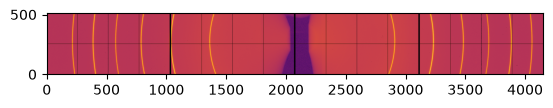

In [5]:
jupyter.display(stack[0]);

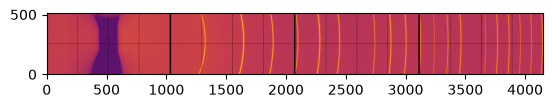

In [6]:
jupyter.display(stack[1]);

## 2. Calibration of two reference frames

The refinement of the goniometer model needs a sensible starting point, which is obtained by calibrating two frames independently, in the usual way: the first one, recorded at $2\theta = 0$, and the second one, recorded 10° further.

The next cell defines the experimental conditions: the wavelength, the detector (with its mask), the calibrant and the image to work on.

In [7]:
# Some parameters like the wavelength, the calibrant and the diffraction image:

wavelength = 0.35413267e-10
detector = pyFAI.detector_factory("eiger2_cdte_2m-w")
detector.mask = msk
calibrant = pyFAI.calibrant.CALIBRANT_FACTORY("LaB6")
calibrant.wavelength = wavelength
img = stack[0]

Uncomment the two cells below to calibrate the first frame interactively: the `Calibration` widget lets one pick a few points along a ring (right-click) and assign them to a given family of Miller indices. The outcome of such a manual picking is hard-coded below, so that this tutorial can be run non-interactively.

In [8]:
# %matplotlib widget
# calib0 = Calibration(img, calibrant=calibrant, wavelength=wavelength, detector=detector)

In [9]:
# %matplotlib inline

Each control point is a triplet: position along the first (slow) axis of the detector, position along the second (fast) axis, and index of the ring it belongs to. A dozen of points spread over three rings is enough to constrain a first geometry.

In [10]:
# A few control points picked manually (see the commented-out cells above)
data0 = [[2.16946196e+02, 1.36495621e+03, 0.00000000e+00],
       [4.98948876e+02, 1.39599020e+03, 0.00000000e+00],
       [1.33985296e+02, 1.37580774e+03, 0.00000000e+00],
       [1.56961272e+02, 1.37212619e+03, 0.00000000e+00],
       [2.06130302e+00, 1.41320516e+03, 0.00000000e+00],
       [1.93958229e+02, 1.36719401e+03, 0.00000000e+00],
       [5.19437953e+01, 1.39644646e+03, 0.00000000e+00],
       [2.34906050e+02, 1.36309143e+03, 0.00000000e+00],
       [1.65042328e+02, 1.37083362e+03, 0.00000000e+00],
       [3.88954898e+02, 2.90280016e+03, 0.00000000e+00],
       [1.58978189e+02, 2.90119235e+03, 0.00000000e+00],
       [2.74014587e+02, 2.91017822e+03, 0.00000000e+00],
       [3.67925601e+02, 2.90473544e+03, 0.00000000e+00],
       [1.92941849e+02, 2.90578101e+03, 0.00000000e+00],
       [1.64969229e+02, 2.90270789e+03, 0.00000000e+00],
       [9.90018845e+01, 1.05369397e+03, 1.00000000e+00],
       [4.44033391e+02, 1.05163881e+03, 1.00000000e+00],
       [1.23955538e+02, 1.04901727e+03, 1.00000000e+00],
       [9.58295565e-01, 1.07477978e+03, 1.00000000e+00],
       [4.13968597e+02, 1.04778491e+03, 1.00000000e+00],
       [7.19943619e+01, 1.05821899e+03, 1.00000000e+00],
       [4.39715964e+01, 1.06440885e+03, 1.00000000e+00],
       [1.83001185e+02, 1.04332263e+03, 1.00000000e+00],
       [1.30993866e+02, 3.22387598e+03, 1.00000000e+00],
       [9.37954748e+01, 3.47184852e+03, 2.00000000e+00],
       [2.89941017e+02, 3.48314557e+03, 2.00000000e+00],
       [3.81939222e+02, 3.47913308e+03, 2.00000000e+00],
       [3.50956230e+02, 3.48117090e+03, 2.00000000e+00],
       [8.19801025e+01, 3.46977222e+03, 2.00000000e+00],
       [4.88998037e+02, 3.46719716e+03, 2.00000000e+00],
       [3.00047818e+01, 3.46169776e+03, 2.00000000e+00],
       [3.61000580e+02, 3.48114746e+03, 2.00000000e+00],
       [1.70020844e+02, 3.47973267e+03, 2.00000000e+00],
       [5.07975952e+02, 8.08918579e+02, 2.00000000e+00],
       [1.59013458e+02, 7.93875427e+02, 2.00000000e+00]]

These points are handed over to an `AbstractCalibration` object configured to run without any graphical interaction, and the geometry is refined starting from a default guess (1 m distance, PONI in the corner of the detector).

At $2\theta = 0^{\circ}$ the arm is at its reference position, hence the detector is perpendicular to the beam: `rot1` and `rot2` are kept fixed at 0, and `rot3` is irrelevant (the system is invariant around this rotation). The wavelength, known from the monochromator, is fixed as well; only the distance and the position of the PONI are actually refined.

In [11]:
calib0 = AbstractCalibration(img, calibrant=calibrant, wavelength=wavelength, detector=detector)
calib0.gui = False
calib0.interactive = False
calib0.preprocess()
calib0.ai = pyFAI.load({"detector":detector, "wavelength": wavelength})
calib0.data = data0
calib0.max_iter = 10

In [12]:
calib0.refine(fixed=["rot3", "wavelength", "rot1", "rot2"])

Before refinement, the geometry is:
Detector Eiger2 CdTe 2M-W	 PixelSize= 75µm, 75µm	 BottomRight (3)
Wavelength= 0.354133 Å
SampleDetDist= 1.000000e+00 m	PONI= 0.000000e+00, 0.000000e+00 m	rot1=0.000000  rot2=0.000000  rot3=0.000000 rad
DirectBeamDist= 1000.000 mm	Center: x=0.000, y=0.000 pix	Tilt= 0.000° tiltPlanRotation= 0.000° λ= 0.354Å
Detector Eiger2 CdTe 2M-W	 PixelSize= 75µm, 75µm	 BottomRight (3)
Wavelength= 0.354133 Å
SampleDetDist= 6.792935e-01 m	PONI= 2.076350e-02, 1.602697e-01 m	rot1=0.000000  rot2=0.000000  rot3=0.000000 rad
DirectBeamDist= 679.293 mm	Center: x=2136.929, y=276.847 pix	Tilt= 0.000° tiltPlanRotation= 0.000° λ= 0.354Å


Detector Eiger2 CdTe 2M-W	 PixelSize= 75µm, 75µm	 BottomRight (3)
Wavelength= 0.354133 Å
SampleDetDist= 6.792935e-01 m	PONI= 2.076350e-02, 1.602697e-01 m	rot1=0.000000  rot2=0.000000  rot3=0.000000 rad
DirectBeamDist= 679.294 mm	Center: x=2136.929, y=276.847 pix	Tilt= 0.000° tiltPlanRotation= 0.000° λ= 0.354Å
Detector Eiger2 CdTe 2M-W	 PixelSize= 75µm, 75µm	 BottomRight (3)
Wavelength= 0.354133 Å
SampleDetDist= 6.792935e-01 m	PONI= 2.076350e-02, 1.602697e-01 m	rot1=0.000000  rot2=0.000000  rot3=0.000000 rad
DirectBeamDist= 679.294 mm	Center: x=2136.929, y=276.847 pix	Tilt= 0.000° tiltPlanRotation= 0.000° λ= 0.354Å


Detector Eiger2 CdTe 2M-W	 PixelSize= 75µm, 75µm	 BottomRight (3)
Wavelength= 0.354133 Å
SampleDetDist= 6.792935e-01 m	PONI= 2.076349e-02, 1.602697e-01 m	rot1=0.000000  rot2=0.000000  rot3=0.000000 rad
DirectBeamDist= 679.294 mm	Center: x=2136.929, y=276.847 pix	Tilt= 0.000° tiltPlanRotation= 0.000° λ= 0.354Å
Detector Eiger2 CdTe 2M-W	 PixelSize= 75µm, 75µm	 BottomRight (3)
Wavelength= 0.354133 Å
SampleDetDist= 6.792935e-01 m	PONI= 2.076349e-02, 1.602697e-01 m	rot1=0.000000  rot2=0.000000  rot3=0.000000 rad
DirectBeamDist= 679.294 mm	Center: x=2136.929, y=276.847 pix	Tilt= 0.000° tiltPlanRotation= 0.000° λ= 0.354Å


Detector Eiger2 CdTe 2M-W	 PixelSize= 75µm, 75µm	 BottomRight (3)
Wavelength= 0.354133 Å
SampleDetDist= 6.792936e-01 m	PONI= 2.076349e-02, 1.602697e-01 m	rot1=0.000000  rot2=0.000000  rot3=0.000000 rad
DirectBeamDist= 679.294 mm	Center: x=2136.929, y=276.847 pix	Tilt= 0.000° tiltPlanRotation= 0.000° λ= 0.354Å
Detector Eiger2 CdTe 2M-W	 PixelSize= 75µm, 75µm	 BottomRight (3)
Wavelength= 0.354133 Å
SampleDetDist= 6.792936e-01 m	PONI= 2.076349e-02, 1.602697e-01 m	rot1=0.000000  rot2=0.000000  rot3=0.000000 rad
DirectBeamDist= 679.294 mm	Center: x=2136.929, y=276.847 pix	Tilt= 0.000° tiltPlanRotation= 0.000° λ= 0.354Å


Once a first geometry is available, many more control points can be extracted automatically: `extract_cpt` looks for the maximum of the signal along every ring predicted by the current geometry (here roughly one point every two degrees of azimuth), and the geometry is refined again with this much larger set of points. The image is finally displayed with the extracted control points overlaid.

Before refinement, the geometry is:
Detector Eiger2 CdTe 2M-W	 PixelSize= 75µm, 75µm	 BottomRight (3)
Wavelength= 0.354133 Å
SampleDetDist= 6.792936e-01 m	PONI= 2.076349e-02, 1.602697e-01 m	rot1=0.000000  rot2=0.000000  rot3=0.000000 rad
DirectBeamDist= 679.294 mm	Center: x=2136.929, y=276.847 pix	Tilt= 0.000° tiltPlanRotation= 0.000° λ= 0.354Å
Detector Eiger2 CdTe 2M-W	 PixelSize= 75µm, 75µm	 BottomRight (3)
Wavelength= 0.354133 Å
SampleDetDist= 6.792952e-01 m	PONI= 2.079060e-02, 1.602582e-01 m	rot1=0.000000  rot2=0.000000  rot3=0.000000 rad
DirectBeamDist= 679.295 mm	Center: x=2136.776, y=277.208 pix	Tilt= 0.000° tiltPlanRotation= 0.000° λ= 0.354Å


Detector Eiger2 CdTe 2M-W	 PixelSize= 75µm, 75µm	 BottomRight (3)
Wavelength= 0.354133 Å
SampleDetDist= 6.792952e-01 m	PONI= 2.079071e-02, 1.602582e-01 m	rot1=0.000000  rot2=0.000000  rot3=0.000000 rad
DirectBeamDist= 679.295 mm	Center: x=2136.777, y=277.209 pix	Tilt= 0.000° tiltPlanRotation= 0.000° λ= 0.354Å
Detector Eiger2 CdTe 2M-W	 PixelSize= 75µm, 75µm	 BottomRight (3)
Wavelength= 0.354133 Å
SampleDetDist= 6.792952e-01 m	PONI= 2.079071e-02, 1.602582e-01 m	rot1=0.000000  rot2=0.000000  rot3=0.000000 rad
DirectBeamDist= 679.295 mm	Center: x=2136.777, y=277.209 pix	Tilt= 0.000° tiltPlanRotation= 0.000° λ= 0.354Å
Detector Eiger2 CdTe 2M-W	 PixelSize= 75µm, 75µm	 BottomRight (3)
Wavelength= 0.354133 Å
SampleDetDist= 6.792952e-01 m	PONI= 2.079071e-02, 1.602582e-01 m	rot1=0.000000  rot2=0.000000  rot3=0.000000 rad
DirectBeamDist= 679.295 mm	Center: x=2136.777, y=277.209 pix	Tilt= 0.000° tiltPlanRotation= 0.000° λ= 0.354Å


Detector Eiger2 CdTe 2M-W	 PixelSize= 75µm, 75µm	 BottomRight (3)
Wavelength= 0.354133 Å
SampleDetDist= 6.792952e-01 m	PONI= 2.079071e-02, 1.602582e-01 m	rot1=0.000000  rot2=0.000000  rot3=0.000000 rad
DirectBeamDist= 679.295 mm	Center: x=2136.777, y=277.209 pix	Tilt= 0.000° tiltPlanRotation= 0.000° λ= 0.354Å
Detector Eiger2 CdTe 2M-W	 PixelSize= 75µm, 75µm	 BottomRight (3)
Wavelength= 0.354133 Å
SampleDetDist= 6.792952e-01 m	PONI= 2.079071e-02, 1.602582e-01 m	rot1=0.000000  rot2=0.000000  rot3=0.000000 rad
DirectBeamDist= 679.295 mm	Center: x=2136.777, y=277.209 pix	Tilt= 0.000° tiltPlanRotation= 0.000° λ= 0.354Å
Detector Eiger2 CdTe 2M-W	 PixelSize= 75µm, 75µm	 BottomRight (3)
Wavelength= 0.354133 Å
SampleDetDist= 6.792952e-01 m	PONI= 2.079071e-02, 1.602582e-01 m	rot1=0.000000  rot2=0.000000  rot3=0.000000 rad
DirectBeamDist= 679.295 mm	Center: x=2136.777, y=277.209 pix	Tilt= 0.000° tiltPlanRotation= 0.000° λ= 0.354Å


Detector Eiger2 CdTe 2M-W	 PixelSize= 75µm, 75µm	 BottomRight (3)
Wavelength= 0.354133 Å
SampleDetDist= 6.792952e-01 m	PONI= 2.079071e-02, 1.602582e-01 m	rot1=0.000000  rot2=0.000000  rot3=0.000000 rad
DirectBeamDist= 679.295 mm	Center: x=2136.777, y=277.209 pix	Tilt= 0.000° tiltPlanRotation= 0.000° λ= 0.354Å
Detector Eiger2 CdTe 2M-W	 PixelSize= 75µm, 75µm	 BottomRight (3)
Wavelength= 0.354133 Å
SampleDetDist= 6.792952e-01 m	PONI= 2.079071e-02, 1.602582e-01 m	rot1=0.000000  rot2=0.000000  rot3=0.000000 rad
DirectBeamDist= 679.295 mm	Center: x=2136.777, y=277.209 pix	Tilt= 0.000° tiltPlanRotation= 0.000° λ= 0.354Å


Detector Eiger2 CdTe 2M-W	 PixelSize= 75µm, 75µm	 BottomRight (3)
Wavelength= 0.354133 Å
SampleDetDist= 6.792952e-01 m	PONI= 2.079071e-02, 1.602582e-01 m	rot1=0.000000  rot2=0.000000  rot3=0.000000 rad
DirectBeamDist= 679.295 mm	Center: x=2136.777, y=277.209 pix	Tilt= 0.000° tiltPlanRotation= 0.000° λ= 0.354Å


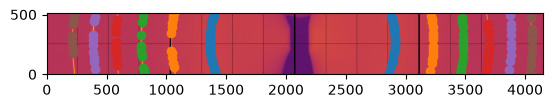

In [13]:
calib0.extract_cpt(pts_per_deg=0.5)
calib0.refine(fixed=["rot3", "wavelength", "rot1", "rot2"])
jupyter.display(img=calib0.img, cp=calib0.peakPicker.points).legend().remove();

The second frame, recorded 10° further, is calibrated in exactly the same way. Uncomment the two cells below to pick the control points manually, otherwise the hard-coded set of the following cell is used.

In [14]:
# %matplotlib widget
# calib1 = Calibration(stack[1], calibrant=calibrant, wavelength=wavelength, detector=detector)

In [15]:
# %matplotlib inline

In [16]:
# A few control points picked manually on the second frame
data1 = [[2.10937576e+02, 1.32242532e+03, 0.00000000e+00],
       [1.19984286e+02, 1.30892846e+03, 0.00000000e+00],
       [4.18939945e+02, 1.31131973e+03, 0.00000000e+00],
       [3.80048807e+02, 1.31824455e+03, 0.00000000e+00],
       [4.96955423e+02, 1.29236931e+03, 0.00000000e+00],
       [4.55998001e+02, 1.30393703e+03, 0.00000000e+00],
       [4.67956588e+02, 1.30136134e+03, 0.00000000e+00],
       [1.56944783e+02, 1.64069626e+03, 1.00000000e+00],
       [2.48968491e+02, 1.64627808e+03, 1.00000000e+00],
       [3.54965225e+02, 1.64354648e+03, 1.00000000e+00],
       [5.03004795e+02, 1.62337791e+03, 1.00000000e+00],
       [3.99949312e+01, 1.62053608e+03, 1.00000000e+00],
       [5.99293251e+01, 1.62508024e+03, 1.00000000e+00],
       [2.19849625e+01, 1.61682495e+03, 1.00000000e+00],
       [1.91057755e+02, 1.89019165e+03, 2.00000000e+00],
       [4.41912514e+02, 1.88242116e+03, 2.00000000e+00],
       [4.01938181e+02, 1.88793859e+03, 2.00000000e+00],
       [1.20966652e+02, 1.88342356e+03, 2.00000000e+00],
       [1.37983368e+02, 1.88583423e+03, 2.00000000e+00],
       [4.65869058e+02, 1.87921598e+03, 2.00000000e+00],
       [2.11963882e+02, 2.09964038e+03, 3.00000000e+00],
       [4.55037476e+02, 2.09079077e+03, 3.00000000e+00],
       [2.60203833e+01, 2.08107749e+03, 3.00000000e+00],
       [3.00431881e+01, 2.08134253e+03, 3.00000000e+00],
       [3.16991794e+02, 2.10070978e+03, 3.00000000e+00],
       [3.27973224e+02, 2.10027699e+03, 3.00000000e+00]]

This time the arm has rotated, so `rot1` and `rot2` have to be refined; only `rot3` (the orientation of the detector around the beam) and the wavelength are kept fixed.

In [17]:
calib1 = AbstractCalibration(stack[1], calibrant=calibrant, wavelength=wavelength, detector=detector)
calib1.max_iter = 10
calib1.gui = False
calib1.interactive = False
calib1.preprocess()
calib1.ai = pyFAI.load({"detector":detector, "wavelength": wavelength})
calib1.data = data1
calib1.refine(fixed=["rot3", "wavelength"])   

Before refinement, the geometry is:
Detector Eiger2 CdTe 2M-W	 PixelSize= 75µm, 75µm	 BottomRight (3)
Wavelength= 0.354133 Å
SampleDetDist= 1.000000e+00 m	PONI= 0.000000e+00, 0.000000e+00 m	rot1=0.000000  rot2=0.000000  rot3=0.000000 rad
DirectBeamDist= 1000.000 mm	Center: x=0.000, y=0.000 pix	Tilt= 0.000° tiltPlanRotation= 0.000° λ= 0.354Å


Detector Eiger2 CdTe 2M-W	 PixelSize= 75µm, 75µm	 BottomRight (3)
Wavelength= 0.354133 Å
SampleDetDist= 6.792103e-01 m	PONI= 6.621322e-02, 1.506045e-01 m	rot1=0.160667  rot2=-0.066212  rot3=0.000000 rad
DirectBeamDist= 689.583 mm	Center: x=540.386, y=274.509 pix	Tilt= 9.950° tiltPlanRotation= -157.487° λ= 0.354Å
Detector Eiger2 CdTe 2M-W	 PixelSize= 75µm, 75µm	 BottomRight (3)
Wavelength= 0.354133 Å
SampleDetDist= 6.791381e-01 m	PONI= 6.620319e-02, 1.505989e-01 m	rot1=0.160661  rot2=-0.066206  rot3=0.000000 rad
DirectBeamDist= 689.509 mm	Center: x=540.524, y=274.492 pix	Tilt= 9.950° tiltPlanRotation= -157.488° λ= 0.354Å


Detector Eiger2 CdTe 2M-W	 PixelSize= 75µm, 75µm	 BottomRight (3)
Wavelength= 0.354133 Å
SampleDetDist= 6.791381e-01 m	PONI= 6.620319e-02, 1.505989e-01 m	rot1=0.160661  rot2=-0.066206  rot3=0.000000 rad
DirectBeamDist= 689.509 mm	Center: x=540.525, y=274.492 pix	Tilt= 9.950° tiltPlanRotation= -157.488° λ= 0.354Å
Detector Eiger2 CdTe 2M-W	 PixelSize= 75µm, 75µm	 BottomRight (3)
Wavelength= 0.354133 Å
SampleDetDist= 6.791381e-01 m	PONI= 6.620319e-02, 1.505989e-01 m	rot1=0.160661  rot2=-0.066206  rot3=0.000000 rad
DirectBeamDist= 689.509 mm	Center: x=540.524, y=274.492 pix	Tilt= 9.950° tiltPlanRotation= -157.488° λ= 0.354Å
Detector Eiger2 CdTe 2M-W	 PixelSize= 75µm, 75µm	 BottomRight (3)
Wavelength= 0.354133 Å
SampleDetDist= 6.791381e-01 m	PONI= 6.620319e-02, 1.505989e-01 m	rot1=0.160661  rot2=-0.066206  rot3=0.000000 rad
DirectBeamDist= 689.509 mm	Center: x=540.524, y=274.492 pix	Tilt= 9.950° tiltPlanRotation= -157.488° λ= 0.354Å


Before refinement, the geometry is:
Detector Eiger2 CdTe 2M-W	 PixelSize= 75µm, 75µm	 BottomRight (3)
Wavelength= 0.354133 Å
SampleDetDist= 6.791381e-01 m	PONI= 6.620319e-02, 1.505989e-01 m	rot1=0.160661  rot2=-0.066206  rot3=0.000000 rad
DirectBeamDist= 689.509 mm	Center: x=540.524, y=274.492 pix	Tilt= 9.950° tiltPlanRotation= -157.488° λ= 0.354Å
Detector Eiger2 CdTe 2M-W	 PixelSize= 75µm, 75µm	 BottomRight (3)
Wavelength= 0.354133 Å
SampleDetDist= 6.792629e-01 m	PONI= 2.404067e-02, 1.619527e-01 m	rot1=0.177030  rot2=-0.004730  rot3=0.000000 rad
DirectBeamDist= 690.055 mm	Center: x=539.075, y=277.023 pix	Tilt= 10.147° tiltPlanRotation= -178.461° λ= 0.354Å


Detector Eiger2 CdTe 2M-W	 PixelSize= 75µm, 75µm	 BottomRight (3)
Wavelength= 0.354133 Å
SampleDetDist= 6.792626e-01 m	PONI= 2.404054e-02, 1.619527e-01 m	rot1=0.177030  rot2=-0.004730  rot3=0.000000 rad
DirectBeamDist= 690.055 mm	Center: x=539.074, y=277.020 pix	Tilt= 10.147° tiltPlanRotation= -178.461° λ= 0.354Å
Detector Eiger2 CdTe 2M-W	 PixelSize= 75µm, 75µm	 BottomRight (3)
Wavelength= 0.354133 Å
SampleDetDist= 6.792626e-01 m	PONI= 2.404054e-02, 1.619527e-01 m	rot1=0.177030  rot2=-0.004730  rot3=0.000000 rad
DirectBeamDist= 690.055 mm	Center: x=539.074, y=277.020 pix	Tilt= 10.147° tiltPlanRotation= -178.461° λ= 0.354Å


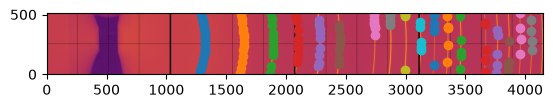

In [18]:
calib1.extract_cpt(pts_per_deg=0.5)
calib1.refine(fixed=["rot3", "wavelength"])
jupyter.display(img=calib1.img, cp=calib1.peakPicker.points).legend().remove();

The two refined geometries can now be compared: the sample-detector distance is identical within a few tens of micrometres, while `rot1` went from 0 to 0.177 rad, i.e. about 10.2°, in reasonable agreement with the 10° step performed by the goniometer. Describing this relation properly, for all the frames at once, is precisely the purpose of the model defined in the next section.

In [19]:
print(calib0.geoRef)
print(calib1.geoRef)

Detector Eiger2 CdTe 2M-W	 PixelSize= 75µm, 75µm	 BottomRight (3)
Wavelength= 0.354133 Å
SampleDetDist= 6.792952e-01 m	PONI= 2.079071e-02, 1.602582e-01 m	rot1=0.000000  rot2=0.000000  rot3=0.000000 rad
DirectBeamDist= 679.295 mm	Center: x=2136.777, y=277.209 pix	Tilt= 0.000° tiltPlanRotation= 0.000° λ= 0.354Å
Detector Eiger2 CdTe 2M-W	 PixelSize= 75µm, 75µm	 BottomRight (3)
Wavelength= 0.354133 Å
SampleDetDist= 6.792626e-01 m	PONI= 2.404054e-02, 1.619527e-01 m	rot1=0.177030  rot2=-0.004730  rot3=0.000000 rad
DirectBeamDist= 690.055 mm	Center: x=539.074, y=277.020 pix	Tilt= 10.147° tiltPlanRotation= -178.461° λ= 0.354Å


## 3. Definition of the goniometer model

The transformation which relates the position of the goniometer (here a single motor, `tth`, expressed in radians) to the six PONI parameters is described by an `ExtendedTransformation` object: every geometrical parameter is given as an analytical expression of the motor position and of a set of refinable parameters.

The model used here has 8 parameters:

* `D`: distance from the rotation axis of the goniometer to the detector,
* `e` and `omega`: amplitude and phase of the eccentricity, i.e. of the offset between the sample and the rotation axis,
* `P1` and `P2`: coordinates of the point of normal incidence on the detector,
* `tth_offset`: zero-offset of the $2\theta$ encoder,
* `rot2`: misalignment between the second axis of the detector and the axis of the goniometer,
* `wlA`: wavelength, expressed in Ångström for a better conditioning of the fit.

The parameters are used in the expressions as follows:

* `dist` and `poni1` carry the eccentricity terms $-e\cdot\cos(2\theta-\delta-\omega)$ and $-e\cdot\sin(2\theta-\delta-\omega)$: if the sample does not sit on the rotation axis of the arm, the sample-detector distance breathes while the arm rotates, and the point of normal incidence moves along the detector accordingly.
* `rot1` $= 2\theta - \delta$ is the rotation of the arm itself, corrected by the encoder offset $\delta$ (`tth_offset`). The angular increments of the goniometer are assumed to be exact, only their origin is refined.
* `rot2` $\propto 1/\cos(2\theta-\delta)$ accounts for the misalignment between the detector and the axis of the goniometer.
* `rot3` $= \pi/2$ since the detector is mounted vertically.
* the wavelength is refined as well, close to the nominal $35\,keV \leftrightarrow 0.354\,\mathring{\text{A}}$.

In [20]:
# Definition of the goniometer transformation function:

goniotrans = ExtendedTransformation(param_names = ["D", "e", "omega", "P1", "P2", "tth_offset", "rot2", "wlA"],
                                    pos_names = ["tth"],
                                    dist_expr="D-e*cos(tth-tth_offset-omega)",
                                    poni1_expr="P1-e*sin(tth-tth_offset-omega)",
                                    poni2_expr="P2",
                                    rot1_expr="tth-tth_offset",
                                    rot2_expr="rot2/cos(tth-tth_offset)",
                                    rot3_expr="pi/2",
                                    wavelength_expr="wlA*1e-10")

The positions of the goniometer are recorded in degrees by the encoder while pyFAI works in radians: the `get_angle` function performs the conversion and is handed over to the refinement object, which calls it for every frame.

In [21]:
def get_angle(idx):
    """get goniometer position in radians, not in degrees"""
    return pi*float(pos[int(idx)])/180
get_angle(5), pos

(0.8725762459515067,
 array([-6.24251171e-03,  9.99482422e+00,  1.99949905e+01,  2.99948640e+01,
         3.99948465e+01,  4.99949362e+01,  5.99948874e+01,  6.99947590e+01,
         7.99947702e+01]))

The refinement is a constrained least-squares fit, hence it needs both a starting guess and a set of bounds for every parameter. The values come from the two single-geometry calibrations performed above: $D \approx 0.68\,m$, $P_1 \approx 2.4\,cm$ and $P_2 \approx 16\,cm$. The eccentricity is started at 1 mm, and the encoder offset is initially frozen by setting both of its bounds to zero: being strongly correlated with `rot1`, it is better released at the very end of the procedure.

In [22]:
# Starting parameters and bounds
param = {"D":0.7, 
         "e":0.001, 
         "omega": 0, 
         "P1": 2.4e-2, 
         "P2": 0.16, 
         "tth_offset": 0,
         "rot2": 0.0,
         "wlA": wavelength*1e+10
         }
bounds = {"D": (0.6, 0.8),
          "e": (-0.1, 0.1),
          "omega": (-pi/2, pi/2),
          "P1": (-0.00, 0.10),
          "P2": (0.15, 0.17),
          "tth_offset": (-0.0, 0.0),
          "rot2": (-0.1, 0.1),
          "wlA": (0.30, 0.40)
         }

The `GoniometerRefinement` object gathers the model, the detector and all the individual frames. The two frames calibrated above are registered together with their control points and their refined geometry, which provides an excellent starting point for the global fit.

In [23]:
gonioref = GoniometerRefinement(param, #initial guess
                                bounds=bounds,
                                pos_function=get_angle,
                                trans_function=goniotrans,
                                detector=detector)
print("Empty refinement object:")
print(gonioref)
gonioref.new_geometry("0", image=stack[0], metadata="0", control_points=calib0.peakPicker.points,
                      geometry=calib0.geoRef, calibrant=calibrant)
gonioref.new_geometry("1", image=stack[1], metadata="1", control_points=calib1.peakPicker.points,
                      geometry=calib1.geoRef, calibrant=calibrant)
print(gonioref)

Empty refinement object:
GoniometerRefinement with 0 geometries labeled: .
GoniometerRefinement with 2 geometries labeled: 0, 1.


Each single geometry can be displayed with the rings of the calibrant computed from its own geometry: a useful visual check before starting the global refinement.

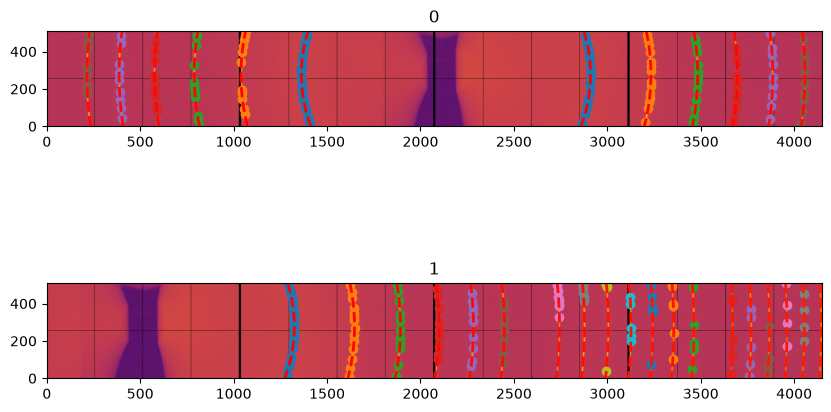

In [24]:
#Display all images with associated calibration:
nimg = len(gonioref.single_geometries)
fig,ax = subplots(nimg, 1, figsize=(10,nimg*3))
for i, sg in enumerate(gonioref.single_geometries.values()):
    jupyter.display(sg=sg, ax=ax[i]).get_legend().remove()

First refinement of the model, on two frames only. Seven parameters out of eight are free, `tth_offset` being still bounded to zero. The cost function — the average of the squared deviation in $2\theta$, in $rad^2$ — drops by nearly four orders of magnitude.

In [25]:
# Initial refinement of the goniometer model with 7 dof
gonioref.refine3()

Free parameters: ['D', 'e', 'omega', 'P1', 'P2', 'rot2', 'wlA']
Fixed: {'tth_offset': 0}
     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 9.247923253170558e-10
           x: [ 6.791e-01 -1.601e-04  2.301e-05  2.113e-02  1.602e-01
               -5.111e-04  3.541e-01]
         nit: 27
         jac: [-1.198e-08  3.214e-09  6.851e-11  2.358e-08  2.047e-07
                3.098e-08  5.878e-08]
        nfev: 216
        njev: 27
 multipliers: []
Constrained Least square 1.230659596254474e-05 --> 9.247923253170558e-10
maxdelta on D: 0.7 --> 0.679110244593449 


np.float64(9.247923253170558e-10)

## 4. Refining the goniometer model with the remaining images

The seven other frames are now added one at a time. For each of them, the geometry predicted by the current model is used to extract the control points automatically, then the model is refined again using all the frames available so far. Adding the frames progressively, rather than all at once, keeps the automatic extraction reliable: every refinement improves the prediction used for the next frame.

The number of usable rings grows quickly with the angle: the first frames provide a few tens of rings while the last ones reach beyond the 200<sup>th</sup> reflection of $LaB_6$.

In [26]:
# This function adds new images to the pool of data used for the refinement.
# A new set of control points is extracted and a refinement step is performed at each iteration.
# The last image of the series is displayed.

def optimize_with_new_images(list_images, pts_per_deg=0.5):
    sg = None
    for fname in list_images:
        print()
        base = str(fname)
        if base not in gonioref.single_geometries:
            print("Working on image #",base)
            sg = gonioref.new_geometry(base, image=stack[fname], metadata=base,
                                       calibrant=calibrant)
            print(sg.extract_cp(pts_per_deg=pts_per_deg))
        gonioref.refine3()
        print("*"*50)
    if sg:
        sg.geometry_refinement.set_param(gonioref.get_ai(sg.get_position()).param)
        jupyter.display(sg=sg).get_legend().remove()


Working on image # 2


ControlPoints instance containing 35 group of point:
LaB6 Calibrant with 460 reflections at wavelength 3.5411603405295596e-11
Containing 35 groups of points:
# s ring 1: 13 points
# t ring 2: 11 points
# u ring 3: 7 points
# v ring 4: 9 points
# w ring 5: 8 points
# x ring 6: 7 points
# y ring 7: 6 points
# z ring 8: 6 points
#aa ring 9: 6 points
#ab ring 10: 6 points
#ac ring 11: 6 points
#ad ring 12: 5 points
#ae ring 14: 5 points
#af ring 15: 5 points
#ag ring 16: 5 points
#ah ring 17: 5 points
#ai ring 18: 5 points
#aj ring 19: 4 points
#ak ring 20: 4 points
#al ring 21: 4 points
#am ring 22: 4 points
#an ring 23: 4 points
#ao ring 24: 4 points
#ap ring 25: 4 points
#aq ring 26: 4 points
#ar ring 27: 4 points
#as ring 28: 4 points
#at ring 29: 4 points
#au ring 30: 4 points
#av ring 31: 3 points
#aw ring 32: 3 points
#ax ring 33: 3 points
#ay ring 34: 3 points
#az ring 35: 3 points
#ba ring 36: 3 points
Free parameters: ['D', 'e', 'omega', 'P1', 'P2', 'rot2', 'wlA']
Fixed: {'tth_of

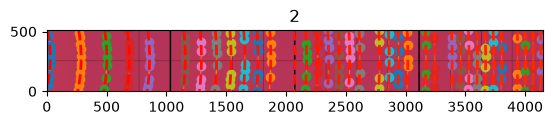

In [27]:
optimize_with_new_images([2])


Working on image # 3


ControlPoints instance containing 50 group of point:
LaB6 Calibrant with 460 reflections at wavelength 3.54072911094368e-11
Containing 50 groups of points:
#bb ring 10: 6 points
#bc ring 11: 6 points
#bd ring 12: 5 points
#be ring 13: 5 points
#bf ring 14: 5 points
#bg ring 15: 5 points
#bh ring 16: 5 points
#bi ring 17: 5 points
#bj ring 18: 3 points
#bk ring 19: 2 points
#bl ring 20: 4 points
#bm ring 21: 2 points
#bn ring 22: 3 points
#bo ring 23: 4 points
#bp ring 24: 4 points
#bq ring 25: 4 points
#br ring 26: 4 points
#bs ring 27: 3 points
#bt ring 28: 4 points
#bu ring 29: 4 points
#bv ring 31: 4 points
#bw ring 32: 3 points
#bx ring 33: 2 points
#by ring 34: 3 points
#bz ring 35: 3 points
#ca ring 36: 3 points
#cb ring 37: 3 points
#cc ring 38: 3 points
#cd ring 39: 3 points
#ce ring 40: 3 points
#cf ring 41: 3 points
#cg ring 42: 3 points
#ch ring 43: 3 points
#ci ring 44: 3 points
#cj ring 45: 1 points
#ck ring 46: 3 points
#cl ring 47: 3 points
#cm ring 48: 3 points
#cn ring

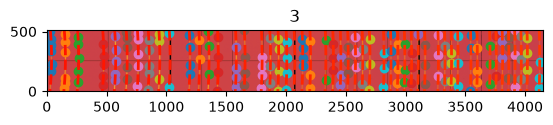

In [28]:
optimize_with_new_images([3])


Working on image # 4


ControlPoints instance containing 66 group of point:
LaB6 Calibrant with 460 reflections at wavelength 3.5404709807852174e-11
Containing 66 groups of points:
#cz ring 25: 3 points
#da ring 26: 4 points
#db ring 27: 3 points
#dc ring 28: 4 points
#dd ring 29: 4 points
#de ring 30: 3 points
#df ring 31: 3 points
#dg ring 32: 3 points
#dh ring 33: 2 points
#di ring 34: 3 points
#dj ring 35: 3 points
#dk ring 36: 3 points
#dl ring 37: 3 points
#dm ring 38: 3 points
#dn ring 39: 3 points
#do ring 40: 3 points
#dp ring 41: 2 points
#dq ring 42: 3 points
#dr ring 43: 2 points
#ds ring 44: 3 points
#dt ring 45: 3 points
#du ring 46: 3 points
#dv ring 47: 3 points
#dw ring 48: 2 points
#dx ring 49: 3 points
#dy ring 50: 3 points
#dz ring 51: 3 points
#ea ring 52: 3 points
#eb ring 53: 3 points
#ec ring 54: 3 points
#ed ring 55: 3 points
#ee ring 56: 3 points
#ef ring 57: 3 points
#eg ring 58: 3 points
#eh ring 59: 3 points
#ei ring 60: 3 points
#ej ring 61: 3 points
#ek ring 62: 3 points
#el ri

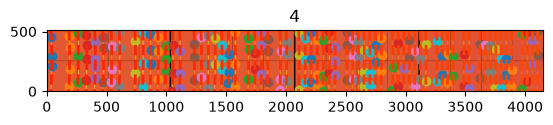

In [29]:
optimize_with_new_images([4])


Working on image # 5


ControlPoints instance containing 77 group of point:
LaB6 Calibrant with 460 reflections at wavelength 3.5402851266345636e-11
Containing 77 groups of points:
#fn ring 47: 3 points
#fo ring 48: 2 points
#fp ring 49: 3 points
#fq ring 50: 3 points
#fr ring 51: 3 points
#fs ring 52: 3 points
#ft ring 53: 1 points
#fu ring 54: 3 points
#fv ring 55: 3 points
#fw ring 56: 1 points
#fx ring 57: 3 points
#fy ring 58: 1 points
#fz ring 59: 3 points
#ga ring 60: 3 points
#gb ring 61: 3 points
#gc ring 62: 3 points
#gd ring 63: 2 points
#ge ring 64: 3 points
#gf ring 65: 3 points
#gg ring 66: 3 points
#gh ring 67: 2 points
#gi ring 68: 2 points
#gj ring 69: 2 points
#gk ring 70: 1 points
#gl ring 71: 2 points
#gm ring 72: 2 points
#gn ring 73: 2 points
#go ring 74: 2 points
#gp ring 75: 2 points
#gq ring 76: 2 points
#gr ring 77: 2 points
#gs ring 78: 2 points
#gt ring 79: 2 points
#gu ring 80: 1 points
#gv ring 82: 2 points
#gw ring 83: 2 points
#gx ring 84: 2 points
#gy ring 85: 2 points
#gz ri

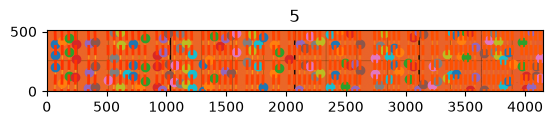

In [30]:
optimize_with_new_images([5])


Working on image # 6


ControlPoints instance containing 86 group of point:
LaB6 Calibrant with 460 reflections at wavelength 3.540151769496548e-11
Containing 86 groups of points:
#im ring 74: 2 points
#in ring 75: 2 points
#io ring 76: 1 points
#ip ring 77: 2 points
#iq ring 78: 2 points
#ir ring 79: 2 points
#is ring 80: 2 points
#it ring 81: 2 points
#iu ring 82: 1 points
#iv ring 83: 2 points
#iw ring 84: 2 points
#ix ring 85: 2 points
#iy ring 86: 2 points
#iz ring 87: 2 points
#ja ring 88: 2 points
#jb ring 89: 2 points
#jc ring 90: 1 points
#jd ring 91: 2 points
#je ring 92: 2 points
#jf ring 94: 2 points
#jg ring 95: 2 points
#jh ring 96: 2 points
#ji ring 97: 2 points
#jj ring 98: 2 points
#jk ring 99: 2 points
#jl ring 100: 1 points
#jm ring 101: 2 points
#jn ring 102: 2 points
#jo ring 103: 2 points
#jp ring 104: 1 points
#jq ring 105: 2 points
#jr ring 106: 2 points
#js ring 107: 2 points
#jt ring 108: 2 points
#ju ring 109: 1 points
#jv ring 110: 2 points
#jw ring 111: 2 points
#jx ring 112: 2 p

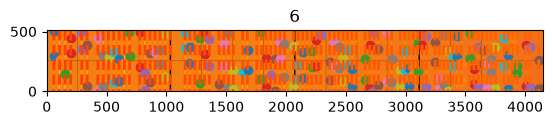

In [31]:
optimize_with_new_images([6])


Working on image # 7


ControlPoints instance containing 94 group of point:
LaB6 Calibrant with 460 reflections at wavelength 3.54006151964593e-11
Containing 94 groups of points:
#lu ring 104: 2 points
#lv ring 105: 2 points
#lw ring 106: 2 points
#lx ring 107: 2 points
#ly ring 108: 2 points
#lz ring 109: 2 points
#ma ring 110: 2 points
#mb ring 111: 2 points
#mc ring 112: 2 points
#md ring 113: 2 points
#me ring 114: 2 points
#mf ring 115: 2 points
#mg ring 116: 2 points
#mh ring 117: 2 points
#mi ring 118: 2 points
#mj ring 119: 2 points
#mk ring 120: 2 points
#ml ring 121: 2 points
#mm ring 122: 2 points
#mn ring 123: 2 points
#mo ring 124: 2 points
#mp ring 125: 2 points
#mq ring 126: 2 points
#mr ring 127: 2 points
#ms ring 128: 2 points
#mt ring 129: 2 points
#mu ring 130: 2 points
#mv ring 131: 2 points
#mw ring 132: 2 points
#mx ring 133: 2 points
#my ring 134: 2 points
#mz ring 135: 2 points
#na ring 136: 2 points
#nb ring 137: 1 points
#nc ring 139: 2 points
#nd ring 140: 2 points
#ne ring 141: 2 

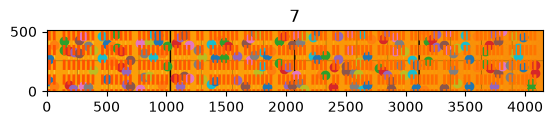

In [32]:
optimize_with_new_images([7])


Working on image # 8


ControlPoints instance containing 98 group of point:
LaB6 Calibrant with 460 reflections at wavelength 3.5400034012253746e-11
Containing 98 groups of points:
#pk ring 140: 2 points
#pl ring 141: 2 points
#pm ring 142: 2 points
#pn ring 143: 2 points
#po ring 144: 2 points
#pp ring 145: 2 points
#pq ring 146: 2 points
#pr ring 147: 2 points
#ps ring 148: 2 points
#pt ring 149: 2 points
#pu ring 150: 2 points
#pv ring 151: 2 points
#pw ring 152: 2 points
#px ring 153: 2 points
#py ring 154: 2 points
#pz ring 155: 2 points
#qa ring 156: 2 points
#qb ring 157: 2 points
#qc ring 158: 2 points
#qd ring 159: 2 points
#qe ring 160: 2 points
#qf ring 161: 2 points
#qg ring 162: 2 points
#qh ring 163: 2 points
#qi ring 164: 2 points
#qj ring 165: 2 points
#qk ring 166: 2 points
#ql ring 167: 2 points
#qm ring 168: 2 points
#qn ring 169: 2 points
#qo ring 171: 2 points
#qp ring 172: 2 points
#qq ring 173: 2 points
#qr ring 174: 2 points
#qs ring 175: 2 points
#qt ring 176: 2 points
#qu ring 177: 

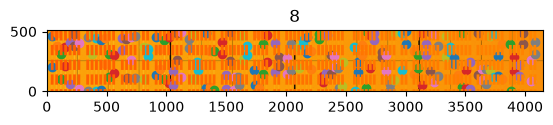

In [33]:
optimize_with_new_images([8])

All nine frames are now part of the refinement. The encoder offset `tth_offset`, frozen until now, can finally be released with reasonable bounds.

In [34]:
gonioref.refine3()
gonioref.set_bounds("tth_offset", -0.1, 0.1)
gonioref.refine3()


Free parameters: ['D', 'e', 'omega', 'P1', 'P2', 'rot2', 'wlA']
Fixed: {'tth_offset': 0}
     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 4.07851409828584e-09
           x: [ 6.790e-01 -3.777e-04  2.276e-05  2.105e-02  1.602e-01
               -4.259e-04  3.540e-01]
         nit: 1
         jac: [ 9.360e-09 -3.868e-07  2.233e-11  2.958e-07  1.252e-08
               -1.074e-07 -7.968e-09]
        nfev: 8
        njev: 1
 multipliers: []
Constrained Least square 4.07851409828584e-09 --> 4.07851409828584e-09
Free parameters: ['D', 'e', 'omega', 'P1', 'P2', 'tth_offset', 'rot2', 'wlA']
Fixed: {}
     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 4.07851409828584e-09
           x: [ 6.790e-01 -3.777e-04  2.276e-05  2.105e-02  1.602e-01
                0.000e+00 -4.259e-04  3.540e-01]
         nit: 1
         jac: [ 9.360e-09 -3.868e-07  2.233e-11  2.958e-07  1.252e-08
                3.762e-0

np.float64(4.07851409828584e-09)

A last refinement, this time with a simplex (Nelder-Mead) algorithm which does not implement bounds.
This validates that the solution found by the constrained optimizer (SLSQP) does not lie against any existing boundaries.

In [35]:
# Refine without any constraint
gonioref.refine3(method="simplex", maxiter=1<<11)

Free parameters: ['D', 'e', 'omega', 'P1', 'P2', 'tth_offset', 'rot2', 'wlA']
Fixed: {}


       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 3.728515592016707e-09
             x: [ 6.796e-01 -4.380e-04 -1.773e+00  2.054e-02  1.608e-01
                 -8.698e-04 -2.299e-04  3.540e-01]
           nit: 1843
          nfev: 2880
 final_simplex: (array([[ 6.796e-01, -4.380e-04, ..., -2.299e-04,
                         3.540e-01],
                       [ 6.796e-01, -4.380e-04, ..., -2.299e-04,
                         3.540e-01],
                       ...,
                       [ 6.796e-01, -4.380e-04, ..., -2.299e-04,
                         3.540e-01],
                       [ 6.796e-01, -4.380e-04, ..., -2.299e-04,
                         3.540e-01]], shape=(9, 8)), array([ 3.729e-09,  3.729e-09,  3.729e-09,  3.729e-09,
                        3.729e-09,  3.729e-09,  3.729e-09,  3.729e-09,
                        3.729e-09]))
Constrained Least square 4.07851409828584e-09 --> 3.728515592016707e-09
maxdelta on omeg

np.float64(3.728515592016707e-09)

## 5. Integration of the complete dataset

The refined model provides the geometry of every frame, hence a `MultiGeometry` integrator can be built to merge the nine images into a single powder diagram spanning 0 to 90° in $2\theta$. The bins which receive no pixel at all — the gaps between the frames and the dead areas of the detector — are set to `NaN` rather than to zero.

In [36]:
# Create a MultiGeometry integrator from the refined geometry:

angles = []
images = []
for sg in gonioref.single_geometries.values():
    angles.append(sg.get_position())
    images.append(sg.image)

multigeo = gonioref.get_mg(angles)
multigeo.radial_range=(0, 90)
print(multigeo)
multigeo.empty = numpy.nan

MultiGeometry integrator with 9 geometries on (0, 90) radial range (2th_deg) and (-180, 180) azimuthal range (chi_deg)


The number of bins is chosen so that the diagram is oversampled by a factor 3 with respect to the angular size of a pixel seen from the sample: with 75 µm pixels at 68 cm, this amounts to more than 40000 points over the 90° range.

In [37]:
# Calculate the optimal number of points for the integration
over = 3
npt = int(over * numpy.deg2rad(max(multigeo.radial_range) - min(multigeo.radial_range)) /
          numpy.arctan2(detector.pixel1, gonioref.nt_param(*gonioref.param).D))
print("Number of bins: ", npt)

Number of bins:  42699


The nine images are integrated in a single pass. The contribution of each individual frame is overlaid as a dashed line: in the regions where two frames overlap, the curves should superimpose, which validates both the geometry and the normalisation of the intensities.

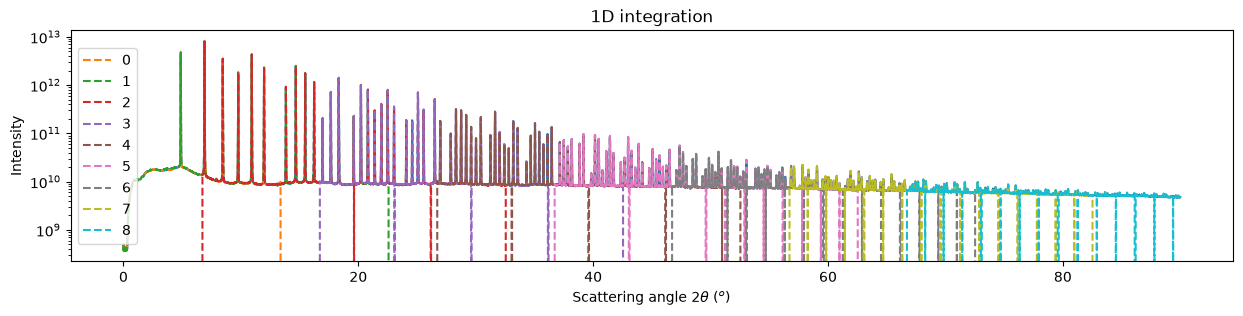

In [38]:
# Integrate the whole set of images in a single run:

res_full = multigeo.integrate1d(images, npt)
fig, ax = subplots(figsize=(15,3))
ax = jupyter.plot1d(res_full, ax=ax)
for sg in gonioref.single_geometries.values():
    ai = gonioref.get_ai(get_angle(sg.label))
    res = ai.integrate1d(sg.image, npt,
                         radial_range=multigeo.radial_range, unit=res_full.unit, 
                         normalization_factor=detector.pixel1*detector.pixel1/(ai.dist**2))
    ax.plot(res.radial, res.intensity, "--", label=sg.label)
ax.legend(loc='center left')
ax.set_yscale("log");

A zoom on the very end of the diagram, where the signal is the weakest, confirms that the peaks of the calibrant (the vertical lines) are still at the expected position at 90°.

(np.int64(37955), np.int64(42698))


(4715696128.0, 6978598912.0)

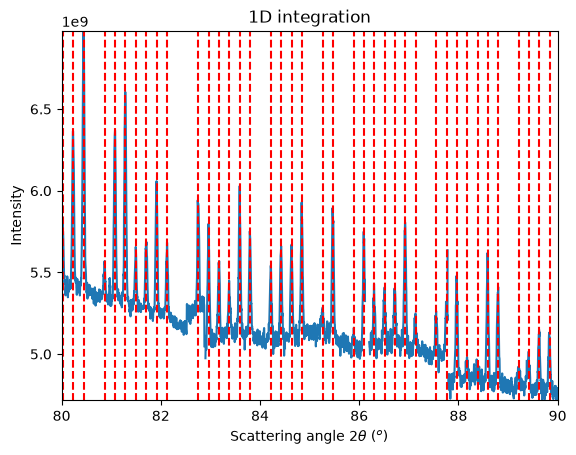

In [39]:
# Zoom on the end of the curve

range_ = 80,90
ax = jupyter.plot1d(res_full, calibrant=calibrant)
ax.set_xlim(*range_)
indices = numpy.where(res_full.radial>=range_[0])[0][0], numpy.where(res_full.radial<=range_[1])[0][-1]
print(indices)
ax.set_ylim(numpy.nanmin(res_full.intensity[indices[0]:indices[1]]),numpy.nanmax(res_full.intensity[indices[0]:indices[1]]))

The calibration of the goniometer is saved as a JSON file which contains everything needed to rebuild the model: the detector, the analytical expressions and the refined parameters. This file can be re-loaded with `pyFAI.goniometer.Goniometer.sload` in order to process any other scan performed with the same setup.

In [40]:
gonioref.save("id22.json")
with open("id22.json") as f:
    print(f.read())

{
  "content": "Goniometer calibration v2",
  "detector": "Eiger2 CdTe 2M-W",
  "detector_config": {
    "pixel1": 7.5e-05,
    "pixel2": 7.5e-05,
    "orientation": 3
  },
  "wavelength": 3.539982954769504e-11,
  "param": [
    0.6795815418326137,
    -0.00043799897481882526,
    -1.7726488456348166,
    0.020536424847962843,
    0.16082469656048587,
    -0.0008698104907279968,
    -0.00022990902202583822,
    0.35399829547695033
  ],
  "param_names": [
    "D",
    "e",
    "omega",
    "P1",
    "P2",
    "tth_offset",
    "rot2",
    "wlA"
  ],
  "pos_names": [
    "tth"
  ],
  "trans_function": {
    "content": "ExtendedTransformation",
    "param_names": [
      "D",
      "e",
      "omega",
      "P1",
      "P2",
      "tth_offset",
      "rot2",
      "wlA"
    ],
    "pos_names": [
      "tth"
    ],
    "dist_expr": "D-e*cos(tth-tth_offset-omega)",
    "poni1_expr": "P1-e*sin(tth-tth_offset-omega)",
    "poni2_expr": "P2",
    "rot1_expr": "tth-tth_offset",
    "rot2_expr":

## 6. First evaluation of the peak profile

The width of the peaks is a direct measurement of the quality of the calibration: any mismatch between the frames, or any residual error in the model, broadens the peaks of the merged diagram. The peaks are located with `scipy.signal.find_peaks`, which also returns their width, converted here into degrees.

Number of peaks found: 211


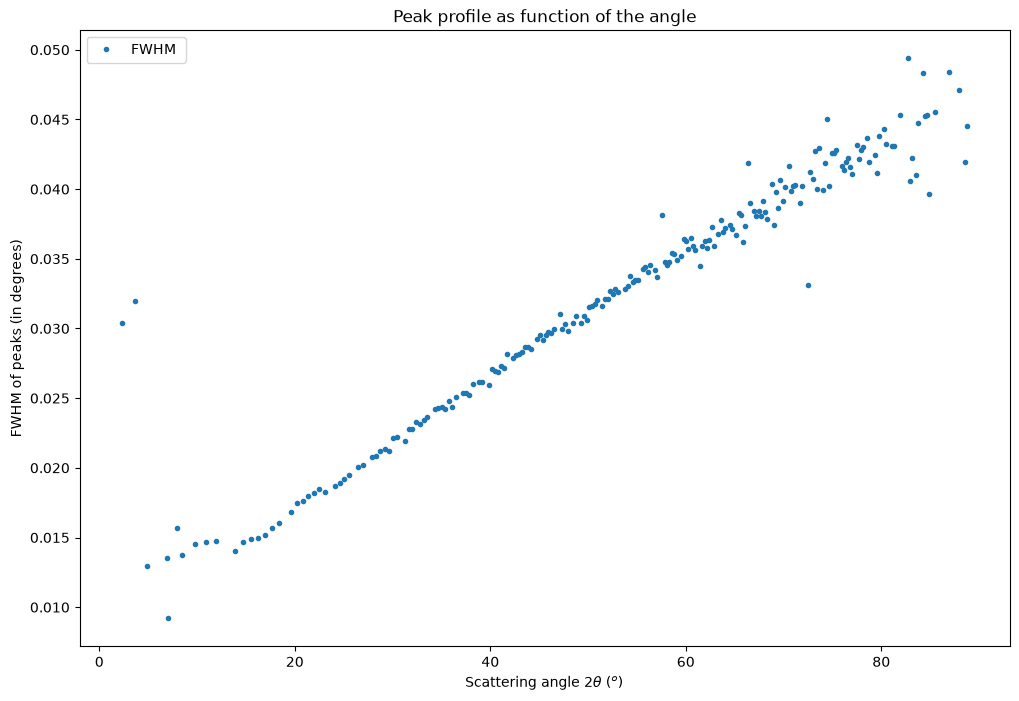

In [41]:
fig, ax = subplots(figsize=(12,8))
# ax.plot(*calc_fwhm(res_full, calibrant), "o", label="FWHM from calibrant")
ax.set_title("Peak profile as function of the angle")
ax.set_ylabel("FWHM of peaks (in degrees)")
ax.set_xlabel(res.unit.label)
resolution = (res_full.radial[1]-res_full.radial[0])
peaks = find_peaks(res_full.intensity, width=(4,25), distance=40, prominence=5e8)
ax.plot(res_full.radial[peaks[0]], resolution*peaks[1]["widths"], ".", label="FWHM ")
ax.legend(loc='upper left')
print("Number of peaks found:",len(peaks[0]))
# 0.01/resolution,0.05/resolution

## 7. Re-extraction of all the control points

Now that a much better model is available, all the control points can be extracted once more, using the refined wavelength and a higher density of points per degree. The final refinement is then performed with all the frames at once.

In [42]:
def reoptimize_with_new_control_points(indices=None, pts_per_deg=0.5):
    if indices is None:
        indices = list(gonioref.single_geometries.keys())
    for label in indices:
        print()
        if label in gonioref.single_geometries:
            print("Extracting frame #", label)
            sg = gonioref.single_geometries[label]
            sg.wavelength = gonioref.param[gonioref.nt_param._fields.index("wlA")]*1e-10
            sg.extract_cp(pts_per_deg=pts_per_deg)
        else:
            continue
    print("*"*50)
    gonioref.refine3()

reoptimize_with_new_control_points(pts_per_deg = 0.7)


Extracting frame # 0



Extracting frame # 1



Extracting frame # 2



Extracting frame # 3



Extracting frame # 4



Extracting frame # 5



Extracting frame # 6



Extracting frame # 7



Extracting frame # 8


**************************************************
Free parameters: ['D', 'e', 'omega', 'P1', 'P2', 'tth_offset', 'rot2', 'wlA']
Fixed: {}
     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 3.6394975541516453e-09
           x: [ 6.795e-01 -4.347e-04 -1.571e+00  2.051e-02  1.608e-01
               -8.741e-04 -2.497e-04  3.540e-01]
         nit: 9
         jac: [-1.505e-07 -3.392e-07  1.957e-10 -1.287e-07 -2.644e-07
               -4.567e-08 -7.104e-08  1.371e-07]
        nfev: 83
        njev: 9
 multipliers: []
Constrained Least square 3.669415201509107e-09 --> 3.6394975541516453e-09
maxdelta on omega: -1.7726488456348166 --> -1.5707963267948966 


In [43]:
gonioref.refine3(method="simplex")

Free parameters: ['D', 'e', 'omega', 'P1', 'P2', 'tth_offset', 'rot2', 'wlA']
Fixed: {}


       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 3.584316622917922e-09
             x: [ 6.797e-01 -5.684e-04 -1.903e+00  2.042e-02  1.610e-01
                 -1.170e-03 -2.134e-04  3.540e-01]
           nit: 887
          nfev: 1497
 final_simplex: (array([[ 6.797e-01, -5.684e-04, ..., -2.134e-04,
                         3.540e-01],
                       [ 6.797e-01, -5.684e-04, ..., -2.134e-04,
                         3.540e-01],
                       ...,
                       [ 6.797e-01, -5.684e-04, ..., -2.134e-04,
                         3.540e-01],
                       [ 6.797e-01, -5.684e-04, ..., -2.134e-04,
                         3.540e-01]], shape=(9, 8)), array([ 3.584e-09,  3.584e-09,  3.584e-09,  3.584e-09,
                        3.584e-09,  3.584e-09,  3.584e-09,  3.584e-09,
                        3.584e-09]))
Constrained Least square 3.6394975541516453e-09 --> 3.584316622917922e-09
maxdelta on ome

np.float64(3.584316622917922e-09)

The final set of parameters. Two comments are worth making here:

* the refined wavelength, 0.35400 Å (35.02 keV), differs by $4\cdot10^{-4}$ in relative value from the nominal one;
* `omega` moves a lot from one refinement to the next while the cost function hardly changes: this parameter is only weakly determined, which is the expected behaviour when `e` is very small. This is discussed in the conclusion.

In [44]:
for i,n in enumerate(gonioref.nt_param._fields):
    print(f"{n:10s} = {gonioref.param[i]}")

D          = 0.6797011386067227
e          = -0.0005684491775946958
omega      = -1.9029326120035024
P1         = 0.020421886659800492
P2         = 0.16103140033195962
tth_offset = -0.0011697030698511175
rot2       = -0.0002134417418080597
wlA        = 0.3539958766274308


The whole dataset is integrated once again, this time with the final model.

In [45]:
multigeo = gonioref.get_mg(angles)
multigeo.radial_range=(0, 90)
print(multigeo)
multigeo.empty = numpy.nan
res_full = multigeo.integrate1d(images, npt)

MultiGeometry integrator with 9 geometries on (0, 90) radial range (2th_deg) and (-180, 180) azimuthal range (chi_deg)


The bins which received no pixel are interpolated from their neighbours, so that the peak search is not disturbed by the `NaN` values, and the calibrant is updated with the refined wavelength.

In [46]:
res_full.intensity[:] = pyFAI.utils.mathutil.interp_filter(res_full.intensity)

In [47]:
calibrant.wavelength = gonioref.param[-1]*1e-10

### Final peak profile

The width of the ~200 peaks of the merged diagram is plotted as a function of the scattering angle. This profile is the convolution of the intrinsic resolution of the setup with whatever residual error is left in the geometrical model: a curve which stays smooth over the whole range, without any jump at the junction between two frames, indicates a consistent calibration.

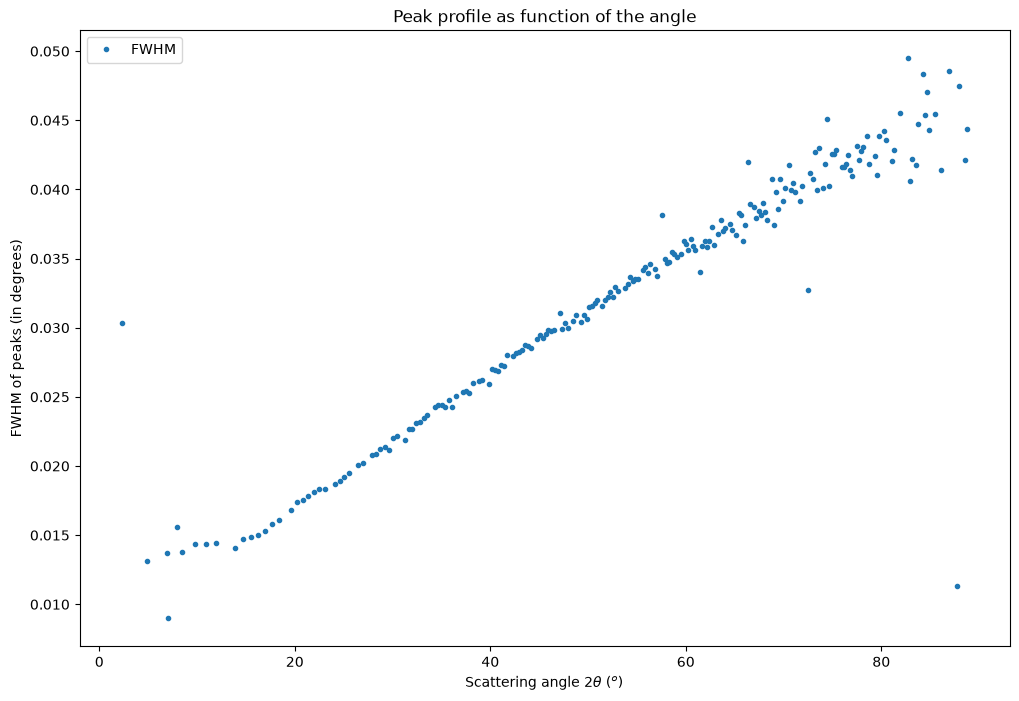

In [48]:
fig, ax = subplots(figsize=(12,8))
ax.set_title("Peak profile as function of the angle")
ax.set_ylabel("FWHM of peaks (in degrees)")
ax.set_xlabel(res.unit.label)
resolution = (res_full.radial[1]-res_full.radial[0])
peaks = find_peaks(res_full.intensity, width=(2,30), distance=40, prominence=5e8)
ax.plot(res_full.radial[peaks[0]], (res_full.radial[1]-res_full.radial[0])*peaks[1]["widths"], ".", label="FWHM")
ax.legend();

## Conclusion

The geometry of the nine frames of this scan is described by a single model with 8 parameters, where an independent calibration of every image would have required 54 of them. All the frames contribute to the same fit, and the model provides the geometry at any position of the arm, including positions which have never been measured. The final cost function, $4.5\cdot10^{-9}\,rad^2$, corresponds to a root-mean-square deviation of $6.7\cdot10^{-5}\,rad$, i.e. 0.0038° in $2\theta$: well below the 0.006° subtended by one pixel at this distance.

### Is the eccentricity of the sample relevant here?

**Not really.** The refined eccentricity, `e` = -0.53 mm, has to be compared with the sample-detector distance, `D` = 679.6 mm: $|e|/D \approx 8\cdot10^{-4}$. In other words, the sample sits on the rotation axis of the goniometer to better than a millimetre, and the modulation of the geometry it induces is three orders of magnitude smaller than the distance itself. The goniometer of ID22 is mechanically very well aligned.

The refinement itself shows the same thing: the phase `omega` of the eccentricity wanders from $10^{-5}$ to $-1.56$ and then $-1.78\,rad$ from one refinement to the next, while the cost function only changes marginally. When `e` tends towards zero, the direction of the offset becomes undefined — the pair (`e`, `omega`) is nearly degenerate, and the data constrain it only weakly. The value of `omega` printed above should therefore not be over-interpreted.

This does not mean that the term should be dropped altogether: 0.53 mm still amounts to 7 pixels of the detector, and the associated modulation of `dist` and `poni1` cannot be entirely absorbed by the other parameters. It does mean, however, that the quality of this calibration is governed by the other terms — the distance, the position of the PONI and the encoder offset ($\delta$ = -0.058°) — and that a setup with a coarser centring of the sample, or a shorter sample-detector distance, would benefit far more from this eccentric model.

The remaining parameters are physically sound as well: the refined wavelength lies within $4\cdot10^{-4}$ of its nominal value, and the misalignment between the detector and the axis of the goniometer, `rot2` = $-1.1\cdot10^{-4}\,rad$ = -0.006°, is at the limit of what can be measured.

The calibration is stored in `id22.json`; it can be re-loaded with `Goniometer.sload("id22.json")` to process any dataset acquired with the same setup, be it another calibrant or the sample of interest.

In [49]:
print(f"execution time: {time.perf_counter()-start_time:.3f}s")

execution time: 106.114s
